<a href="https://colab.research.google.com/github/ayoakin/MIVLDE/blob/LLMProbing/subteams/LLMProbing/notebooks/ExpvsHyp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook to run the experiments related to 2D Linear and eigenvalues

If prompted to restart, press restart.

In [1]:
!pip install numpy==1.25.2

In [2]:
%pip install torch==2.0.0
# Added because the default colab instance now has a newer version of colab
# This ended up breaking the following line below:
# dstr = SymbolicTransformerRegressor(from_pretrained=True)
# This is because PyTorch changed how it loads pickled files
!pip install odeformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# give colab permission to access drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Update these as required
#repo_path = '/content/drive/MyDrive/github/subteams/LLMProbing'
repo_path = "/content/drive/MyDrive/Personlig/AISC Mech Interp Diff eq/MIVLDE/subteams/LLMProbing"
#odeformer_path = '/content/drive/MyDrive/aisc' # This is because I cloned the odeformer repo into my aisc folder
odeformer_path = '/content/drive/MyDrive'
#samples_path = '/content/drive/MyDrive/github/subteams/LLMProbing/local_experiment_data/samples'
samples_path = '/content/drive/MyDrive/aisc/samples'
activations_path = '/content/drive/MyDrive/aisc/activations'
probes_path = '/content/drive/MyDrive/aisc/probes'

In [5]:
import sys
import importlib
sys.path.append(repo_path)
sys.path.append(odeformer_path)

In [6]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import linalg
from tqdm import tqdm
from tqdm.contrib import itertools
from odeformer.metrics import r2_score
import random

In [7]:
from odeformer.model import SymbolicTransformerRegressor
dstr = SymbolicTransformerRegressor(from_pretrained=True)

Downloading...
From (original): https://drive.google.com/uc?id=1L_UZ0qgrBVkRuhg5j3BQoGxlvMk_Pm1W
From (redirected): https://drive.google.com/uc?id=1L_UZ0qgrBVkRuhg5j3BQoGxlvMk_Pm1W&confirm=t&uuid=20b11692-74ff-47bf-a66a-edec5dfeefe8
To: /content/odeformer.pt
100%|██████████| 465M/465M [00:06<00:00, 66.8MB/s]


Loaded pretrained model


In [8]:
model_args = {'beam_size': 10, 'beam_temperature': 0.5}
dstr.set_model_args(model_args)

In [9]:
%load_ext autoreload
%autoreload 2

## Random Sample Generation

In [10]:
c_val = 1
a_val = 1
t = np.linspace(1,10,50)

In [12]:
trajectory = (c_val * np.exp(-a_val * t)).reshape(-1, 1)

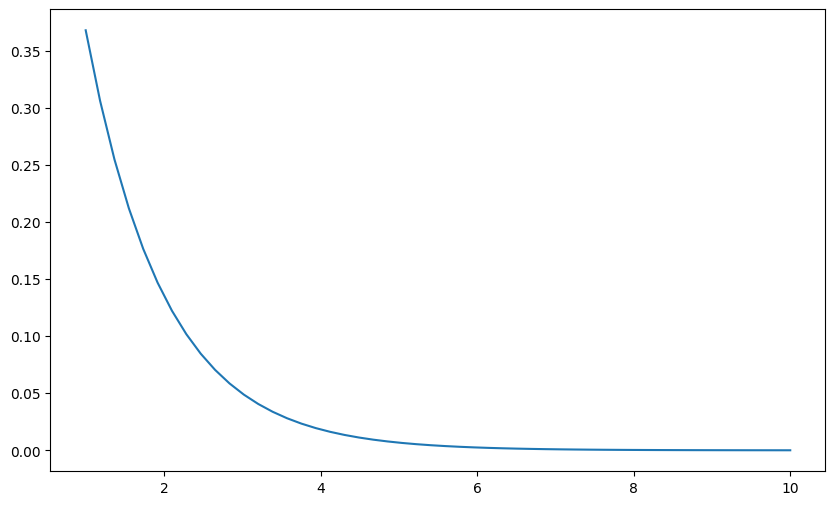

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(t, trajectory)

In [14]:
t0_val = 25

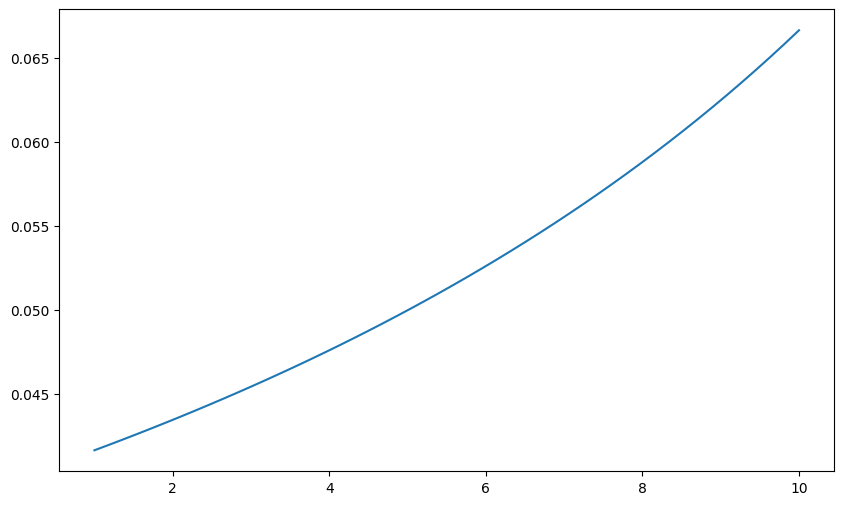

In [16]:
trajectory_hyp = trajectory = (c_val / (t0_val - t)).reshape(-1, 1)

plt.figure(figsize=(10, 6))

plt.plot(t, trajectory_hyp)

## Manual Sample Generation

In [17]:
def random_excluding_range():
    if random.random() < 0.5:
        return random.uniform(-3, -0.2)
    else:
        return random.uniform(0.2, 3)

In [18]:
t_values = np.linspace(1, 10, 50)
a_values = np.linspace(-10,10, 1001)
t0_values = np.linspace(10.1,100,1001)

In [19]:
 def clean_expression(expression):
    # In order to make expressions for equations easier to read
    cleaned = expression.replace('--', '')
    cleaned = cleaned.replace(' -', '-')
    cleaned = cleaned.replace('- ', '-')
    cleaned = cleaned.replace('+-', '-')
    cleaned = cleaned.replace('-+', '-')
    return cleaned

In [20]:
def heaviside(x):
    return 1 if x > 0 else 0

In [21]:
def save_generated_samples(samples, template='sample_man_'):
    for idx, sample in tqdm(enumerate(samples), desc='Saving generated samples'):
        sample_filename = template + f"_{idx}.pt"
        sample_filepath = os.path.join(manual_samples_path, sample_filename)
        os.makedirs(os.path.dirname(sample_filepath), exist_ok=True)
        # Save file using pickle
        with open(sample_filepath, 'wb') as f:
          pickle.dump(sample, f)

In [22]:
dataset_name = 'expvshyp'
manual_samples_path = samples_path + '/' + dataset_name
print(manual_samples_path)

/content/drive/MyDrive/aisc/samples/expvshyp


In [ ]:
manual_samples =[]
for a_val in a_values:
    c_val = random_excluding_range()
    trajectory = (c_val * np.exp(-a_val * t_values)).reshape(-1, 1)
    sample_dict = {
        'times': t_values,
        'trajectory': trajectory
        ,'feature_dict': {"exponential_decay": 1, "a": a_val, "c": c_val, "mag_increase": heaviside(-c_val)}
        ,'expression': clean_expression(f"{c_val} * e^(-{a_val} * t)")
        ,'parameters': {'a': a_val,'c': c_val}

        }
    manual_samples.append(sample_dict)
save_generated_samples(manual_samples, template='sample_' + dataset_name + 'exp')

Saving generated samples: 1001it [00:09, 109.20it/s]


In [ ]:
manual_samples =[]
for t0_val in t0_values:
    c_val = random_excluding_range()
    trajectory = (c_val / (t0_val - t_values)).reshape(-1, 1)
    sample_dict = {
        'times': t_values,
        'trajectory': trajectory
        ,'feature_dict': {"exponential_decay": 0, "t0": t0_val, "c": c_val}
        ,'expression': clean_expression(f"fraq({c_val},({t0_val} - t))")
        ,'parameters': {'a': a_val,'c': c_val}

        }
    manual_samples.append(sample_dict)
save_generated_samples(manual_samples, template='sample_' + dataset_name + 'hyp')

Saving generated samples: 1001it [00:10, 98.64it/s] 


In [ ]:
# Inspect an exponential sample to see its keys and some data
manual_samples_dir = os.fsencode(manual_samples_path)
for sample_file in os.listdir(manual_samples_dir):
  sample_name = os.fsdecode(sample_file)
  exp_sample_path = os.path.join(manual_samples_path, sample_name)
  with open(exp_sample_path, 'rb') as f:
      exp_sample = pickle.load(f)
  print(exp_sample.keys())
  print(exp_sample['expression'])
  print(exp_sample['feature_dict'])
  #print(exp_sample['expression'])
  break

dict_keys(['times', 'trajectory', 'feature_dict', 'expression', 'parameters'])
-1.582581077026355 * e^(10.0 * t)
{'exponential_decay': 1, 'a': -10.0, 'c': -1.582581077026355, 'mag_increase': 1}


## Corresponding Activations Extraction

In [23]:
from src.activation_extraction import ActivationsExtractor

In [24]:
dataset_name = 'expvshyp'
manual_activations_path = f'{activations_path}/{dataset_name}'

In [25]:
act_extractor = ActivationsExtractor()

In [ ]:
act_extractor.extract_activations(dstr, manual_samples_path, manual_activations_path, layers_to_extract=['ffn'])

Extracting Activations:   3%|▎         | 64/2002 [08:40<5:36:02, 10.40s/it]


nan in trajectory of sample expvshypexp_63


Extracting Activations:   5%|▌         | 103/2002 [15:35<6:10:31, 11.71s/it]


nan in trajectory of sample expvshypexp_102


Extracting Activations:   7%|▋         | 133/2002 [21:10<6:24:39, 12.35s/it]

...


nan in trajectory of sample expvshypexp_931


Extracting Activations:  47%|████▋     | 936/2002 [2:14:27<3:06:47, 10.51s/it]


nan in trajectory of sample expvshypexp_935


Extracting Activations: 100%|██████████| 2002/2002 [2:50:16<00:00,  5.10s/it]


[INFO] Activation extraction complete. Activations saved to /content/drive/MyDrive/aisc/activations/expvshyp


In [26]:
# Inspect a manual activation and display its keys and some values
manual_acts_dir = os.fsencode(manual_activations_path)
for acts_file in os.listdir(manual_acts_dir):
  acts_name = os.fsdecode(acts_file)
  manual_acts_path = os.path.join(manual_activations_path, acts_name)
  with open(manual_acts_path, 'rb') as f:
      manual_acts = pickle.load(f)
  print(manual_acts.keys())
  print(manual_acts['feature_dict'])
  print(manual_acts['expression'])
  print(manual_acts['pred_expression'])
  break

dict_keys(['encoder', 'decoder', 'feature_dict', 'pred_expression', 'expression'])
{'exponential_decay': 0, 't0': 10.1899, 'c': 1.0455999212093858, 'r2_score': 0.999995924625496}
0.999995924625496
fraq(1.0455999212093858,(10.1899-t))
x_0' = 0.9563 * (x_0)**2

{'exponential_decay': 0, 't0': 10.1899, 'c': 1.0455999212093858, 'r2_score': 0.999995924625496}


Check number of samples above certain thresholds

In [35]:
dataset_name = 'expvshyp'
manual_activations_path = f'{activations_path}/{dataset_name}'
manual_acts_dir = os.fsencode(manual_activations_path)
count = 0
count_minus1 = 0
count_50 = 0
count_90 = 0

for acts_file in os.listdir(manual_acts_dir):
  acts_name = os.fsdecode(acts_file)
  manual_acts_path = os.path.join(manual_activations_path, acts_name)
  with open(manual_acts_path, 'rb') as f:
      manual_acts = pickle.load(f)

  count +=1
  if (manual_acts['feature_dict']['r2_score'] >= -1):
    count_minus1 += 1
  if (manual_acts['feature_dict']['r2_score'] >= 0.5):
    count_50 += 1
  if (manual_acts['feature_dict']['r2_score'] >= 0.9):
    count_90 += 1
print("All: ", count)
print("r2 >= -1: " ,  count_minus1)
print("r2 >= 0.5: ", count_50)
print("r2 >= 0.9: ", count_90)

All:  2002
r2 >= -1:  1857
r2 >= 0.5:  1391
r2 >= 0.9:  1348


## Probe Training

In [37]:
import experiments

In [38]:
dir(experiments)
# Current experiment functions supported:
#   - separability_testing

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'load_and_run_r2_prediction_experiment',
 'load_and_run_scalar_prediction_experiment',
 'r2_prediction_experiment',
 'run_experiment',
 'scalar_prediction_experiment',
 'scalar_prediction_experiment_w_solver',
 'separability_testing']

In [39]:
probes_path

'/content/drive/MyDrive/aisc/probes'

In [40]:
dataset_name

'expvshyp'

In [42]:
target_feature = 'exponential_decay'
#r2_threshold = -1
r2_threshold = 0.9
probes_path_full = f'{probes_path}/{dataset_name}/{target_feature}/{r2_threshold}'

In [43]:
layers = [idx for idx in range(0, 16)]

expt_results = experiments.run_experiment.scalar_prediction_experiment_w_solver(target_feature=target_feature, activations_path=manual_activations_path, \
                     probes_path=probes_path_full, \
                     layers=layers, r2_threshold=r2_threshold)
# save experiment results
with open(f'{probes_path_full}/experiment_data.pt', 'wb') as f:
    pickle.dump(expt_results, f)


Training on each layer:   0%|          | 0/16 [00:00<?, ?it/s]

Regression probe trained on layer 0: Test Set Loss 0.09406621406067833



Training on each layer:   6%|▋         | 1/16 [00:49<12:15, 49.02s/it]

Saved state dictionary to /content/drive/MyDrive/aisc/probes/expvshyp/exponential_decay/0.9/probe_exponential_decay_0_0.pt



Training on each layer:  12%|█▎        | 2/16 [01:21<09:07, 39.13s/it]

...

Regression probe trained on layer 13: Test Set Loss 0.004656610698816144
Saved state dictionary to /content/drive/MyDrive/aisc/probes/expvshyp/exponential_decay/0.9/probe_exponential_decay_13_0.pt



Training on each layer:  94%|█████████▍| 15/16 [09:38<00:35, 35.71s/it]

Regression probe trained on layer 14: Test Set Loss 0.016822421759713165
Saved state dictionary to /content/drive/MyDrive/aisc/probes/expvshyp/exponential_decay/0.9/probe_exponential_decay_14_0.pt



Training on each layer: 100%|██████████| 16/16 [10:29<00:00, 39.33s/it]

Regression probe trained on layer 15: Test Set Loss 0.004708543597980726
Saved state dictionary to /content/drive/MyDrive/aisc/probes/expvshyp/exponential_decay/0.9/probe_exponential_decay_15_0.pt


In [45]:
layers = [idx for idx in range(0, 16)]

expt_results = experiments.run_experiment.separability_testing_w_solver(target_feature=target_feature, activations_path=manual_activations_path, \
                     probes_path=probes_path_full, \
                     layers=layers, r2_threshold=r2_threshold)
with open(f'{probes_path_full}/experiment_data.pt', 'wb') as f:
    pickle.dump(expt_results, f)

Probe trained on layer 0: Test Set Loss 0.37766801065473415, Test Set Accuracy 0.9253731369972229
Saved state dictionary to /content/drive/MyDrive/aisc/probes/expvshyp/exponential_decay/0.9/probe_exponential_decay_0_0.pt
Probe trained on layer 1: Test Set Loss 0.18291052063899255, Test Set Accuracy 0.9402984976768494
Saved state dictionary to /content/drive/MyDrive/aisc/probes/expvshyp/exponential_decay/0.9/probe_exponential_decay_1_0.pt
Probe trained on layer 2: Test Set Loss 0.09778838371162984, Test Set Accuracy 0.9850746393203735
Saved state dictionary to /content/drive/MyDrive/aisc/probes/expvshyp/exponential_decay/0.9/probe_exponential_decay_2_0.pt
Probe trained on layer 3: Test Set Loss 0.07814074274319321, Test Set Accuracy 0.9925373196601868
Saved state dictionary to /content/drive/MyDrive/aisc/probes/expvshyp/exponential_decay/0.9/probe_exponential_decay_3_0.pt
Probe trained on layer 4: Test Set Loss 0.013698540516753696, Test Set Accuracy 1.0
Saved state dictionary to /conte

In [46]:
expt_results

,layer,test_loss,test_accuracy,test_fail_ids,final_train_loss,final_train_accuracy,final_val_loss,final_val_accuracy
0,0,0.377668,0.925373,"[expvshypexp_979, expvshypexp_781, expvshypexp...",2.439210e-05,1.000000,0.475573,0.918519
1,1,0.182911,0.940298,"[expvshypexp_979, expvshypexp_886, expvshypexp...",2.766747e-07,1.000000,0.123879,0.977778
2,2,0.097788,0.985075,"[expvshypexp_492, expvshypexp_479]",4.195547e-06,1.000000,0.111975,0.985185
3,3,0.078141,0.992537,[expvshypexp_674],5.737726e-04,1.000000,0.088839,0.985185
4,4,0.013699,1.000000,[],7.671920e-03,0.998146,0.012512,1.000000
5,5,0.018078,1.000000,[],1.243064e-02,0.998146,0.014155,1.000000
6,6,0.010387,1.000000,[],2.026021e-02,0.997220,0.040303,0.992593
7,7,0.030208,0.992537,[expvshypexp_492],4.250330e-02,0.990732,0.013121,1.000000
8,8,0.014141,1.000000,[],2.340964e-02,0.994439,0.017654,0.992593
9,9,0.014647,1.000000,[],7.346155e-03,0.998146,0.015504,1.000000


In [47]:
expvshyp_090 = expt_results
acc_090 =  expvshyp_090['test_accuracy']
loss_090 = expvshyp_090['test_loss']

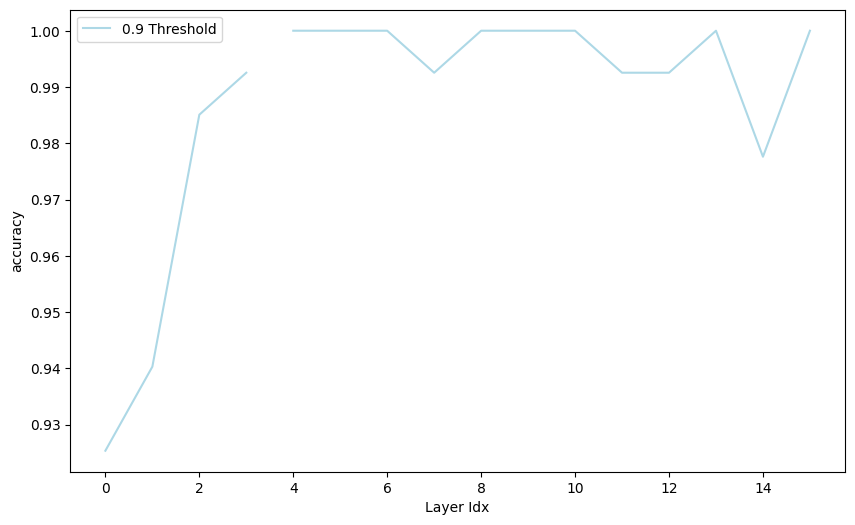

In [49]:
plt.figure(figsize=(10, 6))

#plt.plot(layers[:4], acc_100[:4], label='HypvsHyp', color = 'blue')
#plt.plot(layers[4:], acc_100[4:], color = 'blue' )
plt.plot(layers[:4], acc_090[:4], label='0.9 Threshold', color = 'lightblue')
plt.plot(layers[4:], acc_090[4:], color = 'lightblue' )

plt.xlabel("Layer Idx")
plt.ylabel("accuracy")
plt.legend()

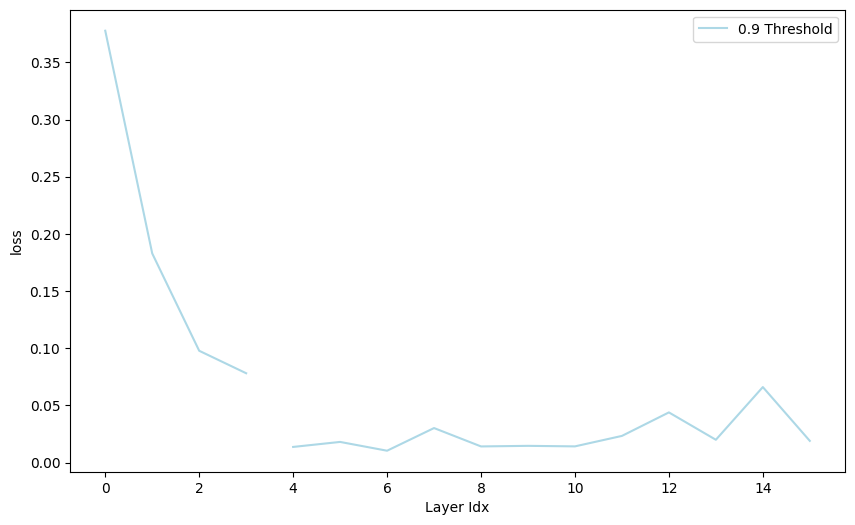

In [50]:
plt.figure(figsize=(10, 6))

#plt.plot(layers[:4], loss_100[:4], label='HypvsHyp', color = 'blue')
#plt.plot(layers[4:], loss_100[4:], color = 'blue' )
plt.plot(layers[:4], loss_090[:4], label='0.9 Threshold', color = 'lightblue')
plt.plot(layers[4:], loss_090[4:], color = 'lightblue' )

plt.xlabel("Layer Idx")
plt.ylabel("loss")
plt.legend()